1.Loading Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use relative path (best for GitHub)
df = pd.read_csv("C:/Users/Rudy2/capstone/unfc-capstone-traffic-forecasting/data/processed/svc_summary_clean.csv")

df.head()


,count_id,location_name,count_date_start,count_date_end,avg_daily_vol,avg_speed,avg_85th_percentile_speed,avg_95th_percentile_speed,avg_heavy_pct,congestion_target,congestion_level
0,3014976,Senlac Rd: Churchill Ave - Horsham Ave,2026-01-20,2026-01-22,7233.0,37.3,43.9,48.5,0.069,7233.0,Medium
1,3015033,Beachell St: Eglinton Ave E - Luella St,2026-01-20,2026-01-22,828.7,31.0,39.8,44.6,0.069,828.7,Low
2,3015251,Brookshire Blvd: Lanewood Cres - Blairwood Ter,2026-01-20,2026-01-22,341.7,29.3,38.4,44.0,0.069,341.7,Low
3,3015035,Dufferin St: Wenderly Dr - Claver Ave,2026-01-20,2026-01-22,29086.7,40.4,51.5,57.2,0.069,29086.7,Severe
4,3015036,Bremner Blvd: Olympic Park Trl - Rees St,2026-01-20,2026-01-22,6648.3,29.9,38.4,43.8,0.069,6648.3,Medium


2. Inspecting Data Structure and Variables 

In [2]:
df.shape, df.columns.tolist()
df.info()
df.describe(include="all").T.head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44470 entries, 0 to 44469
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   count_id                   44470 non-null  int64  
 1   location_name              44470 non-null  object 
 2   count_date_start           44470 non-null  object 
 3   count_date_end             44470 non-null  object 
 4   avg_daily_vol              44470 non-null  float64
 5   avg_speed                  44470 non-null  float64
 6   avg_85th_percentile_speed  44470 non-null  float64
 7   avg_95th_percentile_speed  44470 non-null  float64
 8   avg_heavy_pct              44470 non-null  float64
 9   congestion_target          44470 non-null  float64
 10  congestion_level           44470 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
count_id,44470.0,NaN,NaN,NaN,1076364.164156,881741.752792,3.0,347997.0,911850.0,1570974.5,3015419.0
location_name,44470,14109,Islington Ave: Dixon Rd - Kingsview Blvd,556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_date_start,44470,3827,2009-10-20,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count_date_end,44470,4024,2009-10-22,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_daily_vol,44470.0,NaN,NaN,NaN,10489.24277,9890.232381,1.0,1922.175,8903.35,15729.225,117916.0
avg_speed,44470.0,NaN,NaN,NaN,36.999121,5.767294,10.0,36.8,36.8,36.8,118.4
avg_85th_percentile_speed,44470.0,NaN,NaN,NaN,45.342438,6.083871,16.3,44.9,44.9,44.9,147.7
avg_95th_percentile_speed,44470.0,NaN,NaN,NaN,50.636685,7.480162,18.1,50.0,50.0,50.0,155.9
avg_heavy_pct,44470.0,NaN,NaN,NaN,0.06921,0.007633,0.0,0.069,0.069,0.069,0.7
congestion_target,44470.0,NaN,NaN,NaN,10489.24277,9890.232381,1.0,1922.175,8903.35,15729.225,117916.0


3. Timestamp Consistency 

In [3]:
df["count_date_start"] = pd.to_datetime(df["count_date_start"], errors="coerce")
df["count_date_end"]   = pd.to_datetime(df["count_date_end"], errors="coerce")

# basic checks
(df["count_date_start"].isna().sum(), df["count_date_end"].isna().sum())


(np.int64(0), np.int64(0))

4. Derived Fields For EDA

In [4]:

df["year"] = df["count_date_start"].dt.year
df["month"] = df["count_date_start"].dt.month
df["dayofweek"] = df["count_date_start"].dt.dayofweek  # Mon=0
df["week"] = df["count_date_start"].dt.isocalendar().week.astype(int)

# duration (days)
df["window_days"] = (df["count_date_end"] - df["count_date_start"]).dt.days
df[["count_date_start","count_date_end","window_days"]].head()


,count_date_start,count_date_end,window_days
0,2026-01-20,2026-01-22,2
1,2026-01-20,2026-01-22,2
2,2026-01-20,2026-01-22,2
3,2026-01-20,2026-01-22,2
4,2026-01-20,2026-01-22,2


Visualtion 1. Plot 1 — Traffic volume trends over time

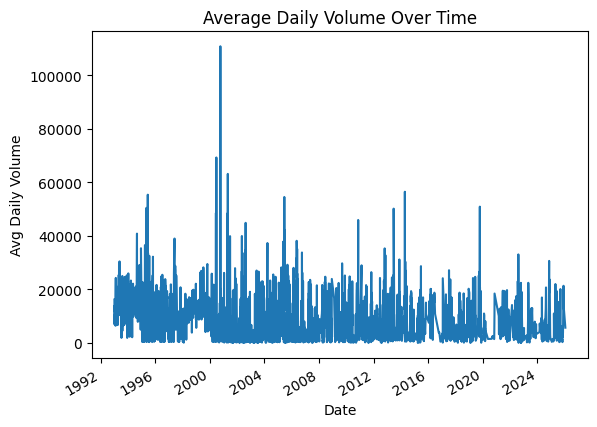

In [5]:
daily = df.groupby("count_date_start")["avg_daily_vol"].mean().sort_index()

plt.figure()
daily.plot()
plt.title("Average Daily Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Daily Volume")
plt.show()


Visualization 2: Plot 2 — Weekly seasonality 

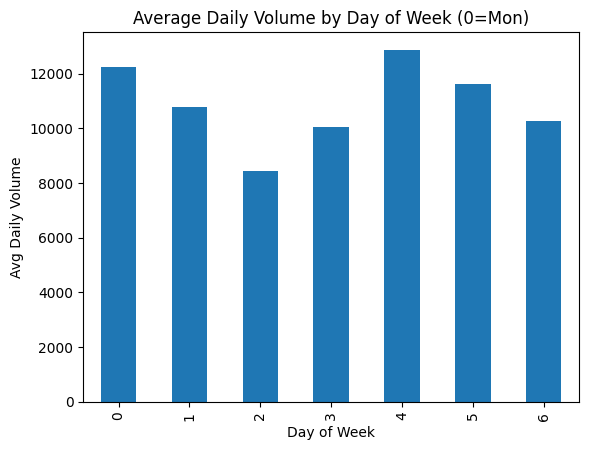

In [6]:
dow = df.groupby("dayofweek")["avg_daily_vol"].mean()

plt.figure()
dow.plot(kind="bar")
plt.title("Average Daily Volume by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Avg Daily Volume")
plt.show()


Visualization 3: Plot 3 — Peak vs off-peak pattern (Task: peak vs off-peak)

Column avg_wkdy_pm_peak_vol not found. We'll use speed as an alternative.


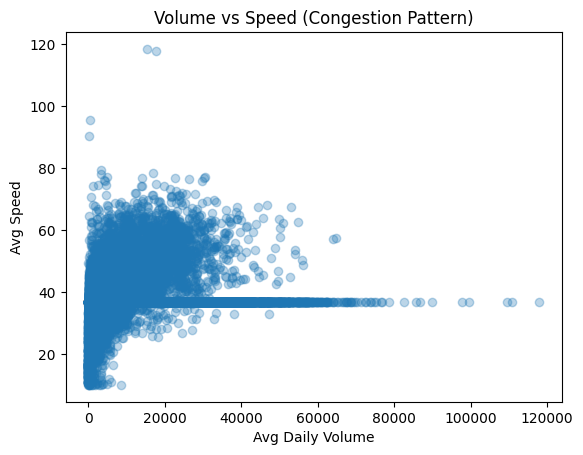

In [8]:
if "avg_wkdy_pm_peak_vol" in df.columns:
    compare = df[["avg_daily_vol","avg_wkdy_pm_peak_vol"]].dropna()

    plt.figure()
    plt.scatter(compare["avg_daily_vol"], compare["avg_wkdy_pm_peak_vol"], alpha=0.3)
    plt.title("Peak vs Average Volume")
    plt.xlabel("Avg Daily Volume")
    plt.ylabel("Weekday PM Peak Volume")
    plt.show()
else:
    print("Column avg_wkdy_pm_peak_vol not found. We'll use speed as an alternative.")


    plt.figure()
plt.scatter(df["avg_daily_vol"], df["avg_speed"], alpha=0.3)
plt.title("Volume vs Speed (Congestion Pattern)")
plt.xlabel("Avg Daily Volume")
plt.ylabel("Avg Speed")
plt.show()



5. Missing Values and Anomalies 

In [9]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(15)


count_id                     0.0
location_name                0.0
count_date_start             0.0
count_date_end               0.0
avg_daily_vol                0.0
avg_speed                    0.0
avg_85th_percentile_speed    0.0
avg_95th_percentile_speed    0.0
avg_heavy_pct                0.0
congestion_target            0.0
congestion_level             0.0
year                         0.0
month                        0.0
dayofweek                    0.0
week                         0.0
dtype: float64

In [10]:
# simple anomaly checks
df[["avg_daily_vol","avg_speed"]].describe()


,avg_daily_vol,avg_speed
count,44470.000000,44470.000000
mean,10489.242770,36.999121
std,9890.232381,5.767294
min,1.000000,10.000000
25%,1922.175000,36.800000
50%,8903.350000,36.800000
75%,15729.225000,36.800000
max,117916.000000,118.400000


In [11]:
# rows with suspicious values
df[(df["avg_daily_vol"] < 0) | (df["avg_speed"] < 0)].head()


,count_id,location_name,count_date_start,count_date_end,avg_daily_vol,avg_speed,avg_85th_percentile_speed,avg_95th_percentile_speed,avg_heavy_pct,congestion_target,congestion_level,year,month,dayofweek,week,window_days


6.Correlations  

In [13]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr(numeric_only=True)

# show strongest correlations with avg_daily_vol
corr["avg_daily_vol"].sort_values(ascending=False).head(15)


avg_daily_vol                1.000000
congestion_target            1.000000
avg_speed                    0.205225
avg_85th_percentile_speed    0.169986
avg_95th_percentile_speed    0.135147
window_days                  0.008764
month                        0.006639
week                         0.005148
avg_heavy_pct                0.002469
dayofweek                   -0.027771
count_id                    -0.204635
year                        -0.220846
Name: avg_daily_vol, dtype: float64

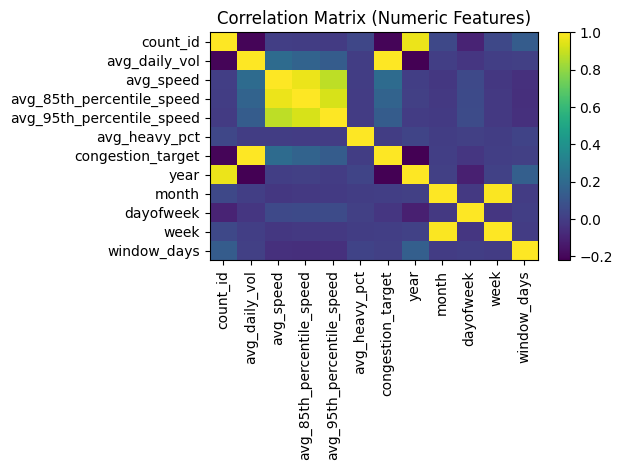

In [14]:
plt.figure()
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix (Numeric Features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()


Summary cell:

